# Weather Classification Technical Report
CPSC-322 Data Science | Fall 2025 | Written by Aiden Tabrah & Valon Haslem

### Introduction


#### 1) Overview:
[Weather Category Dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset) is a .csv file with 96.5k instances and 12 attributes. The attribute being selected for classification is the "summary" attribute, which weather predictors use to classify weather conditions in short descriptions.

#### 2) Description:
We will be using 10 non-classification attributes for training our classifiers, out of the 12. The layoyut of the dataset is as follows:  
  
**Summary**                     - Various classification labels such as "Partly Cloudy" or "Mostly Cloudy"   
 ___
**Date**                 - Dates from 2005 to 2016  
**Precip-type**               - rain, snow, or other   
**Temperature (C)**                 - Temperature in celsius from -21.8 to 39.9  
**Apparent Temperature (C)**                   -  How it "feels" outside due to wind or other conditions. Ranges from -27.7 to 39.3  
**Humidity**                      - Percentage between 0.00 and 1.00  
**Wind Speed (km/h)**           - Wind speed in kilometers per hour, from 0 to 63.9  
**Wind Bearing (degrees)**              - Wind direction from 0 to 359  
**Visibility (km)**                 - How far one should be able to see, in kilometers.  
**Pressure (millibars)**               - Pressure from 0 to 1.05k  
**Loud Cover** - Potentially cloud cover? All data values are 0.0 though. (Will not be used)  
**Daily Summary** - A more descriptive classification of the data, that isn't standardized and varies more often. (Will not be used)


#### 3) Findings:
We tested the Random Forest, Decision Tree, and Naive Bayes after discretizing our continuous variables into 'high' or 'low'. The Random Forest got 35% accuracy, Decision Tree got 40%, and Naive Bayes got 39%. By accuracy, our best classifier is the Decision Tree, but Random Forest actually produced the best precision at 32% whereas Naive Bayes and Decision Tree produced 30% and 24% precision respectively. We conclude that the data distribution restricts the accuracy of any classifier since four classes - overcase, mostly cloudy, and partly cloudy, foggy - are significantly overrepresented and thus overpredicted in the classifer. This could be addressed partially with stratified k-fold splits, but won't totally address the issue for any small k. Future work should aim to use more distributed datasets or restrict the number of possible classes.

#### Imports

In [2]:
from tabulate import tabulate
import importlib

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.mypytable
importlib.reload(mysklearn.mypytable)
from mysklearn.mypytable import MyPyTable 

import mysklearn.myclassifiers
importlib.reload(mysklearn.myclassifiers)
from mysklearn.myclassifiers import MyDecisionTreeClassifier
from mysklearn.myclassifiers import MyNaiveBayesClassifier

import mysklearn.myevaluation
importlib.reload(mysklearn.myevaluation)
import mysklearn.myevaluation as myevaluation
from mysklearn.myclassifiers import MyRandomForestClassifier



# Constants:
k = 10
seed = 1

#### Data Cleaning / Setup

There were a couple attributes that needed cleaning, and we used these strategies for the following attribtues:
- Pressure - 0.0 pressure is not a legitimate value, and we replaced those invalid values with the mean pressure of the dataset.
- Missing values - any instance with a missing value is removed from the dataset.
- Date - needs to be dropped, not a useful thing.
- Precip-type - Since this has a ton of other values, it should be dropped.
- All attributes - all remaining attributes besides the classification are continuous. They should be normalized.

In [3]:

weather_data = MyPyTable().load_from_file("input-data/weatherHistory.csv")
weather_data.remove_rows_with_missing_values()
weather_data.save_to_file("output-data/weatherHistory_cleaned.csv")

weather_data.replace_column("Formatted Date", myutils.convert_date_to_numeric(weather_data.get_column("Formatted Date")))
# replace pressure zero values with mean

weather_data.replace_column('Pressure (millibars)', myutils.convert_zeros_to_mean(weather_data.get_column('Pressure (millibars)')))
weather_data.normalize_values(["Formatted Date", "Temperature (C)","Apparent Temperature (C)",
                               "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])

weather_data.save_to_file("output-data/weatherHistory_normalized_and_cleaned.csv")

#### Loading data

In [4]:
weather_data = MyPyTable().load_from_file("output-data/weatherHistory_normalized_and_cleaned.csv")

all_ys = [val[0] for val in weather_data.select_columns(["Summary"]).data]
weather_x_data = weather_data.select_columns(["Formatted Date", "Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])
all_xs = weather_x_data.data


Should we use the boxplots to determine our discretizer? we could just discretize by mean (high low) or also use first and third quadrants. will probably need to explain our decisions in the presentation.

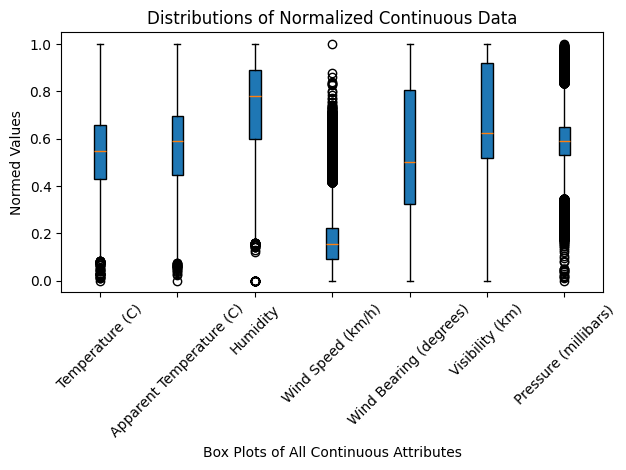

In [5]:
# box plots for continuous data
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
weather_cts_data = weather_data.select_columns(["Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]).data
weather_cts_data_transposed = [list(row) for row in zip(*weather_cts_data)]

for idx, data in enumerate(weather_cts_data_transposed):
    # first, normalize it
    new_data = myutils.norm_list(data)
    ax.boxplot(new_data, positions = [idx], patch_artist=True)


ax.set_xticks(range(len(weather_cts_data_transposed)))
ax.set_xticklabels(["Temperature (C)", 
                    "Apparent Temperature (C)",
                    "Humidity", 
                    "Wind Speed (km/h)", 
                    "Wind Bearing (degrees)", 
                    "Visibility (km)", 
                    "Pressure (millibars)"])
plt.xticks(rotation = 45)
ax.set_title("Distributions of Normalized Continuous Data")
ax.set_ylabel('Normed Values')
ax.set_xlabel('Box Plots of All Continuous Attributes')
plt.tight_layout()
plt.show()


#### Relationships

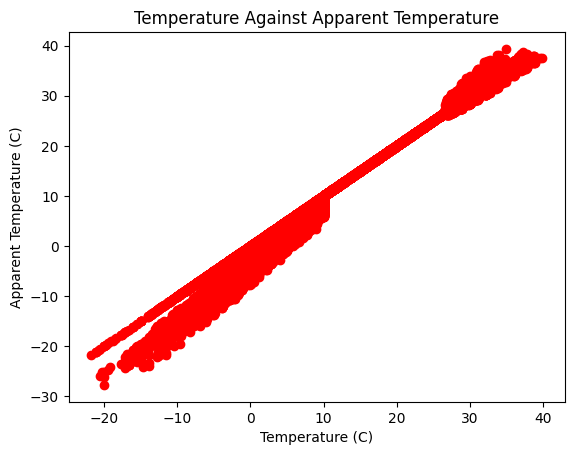

In [16]:
humidity = weather_data.get_column('Humidity')
temperature = weather_data.get_column('Temperature (C)')
pressure = weather_data.get_column('Pressure (millibars)')
app_temp = weather_data.get_column('Apparent Temperature (C)')

plt.figure()
plt.scatter(x = temperature, y = app_temp, c = 'red')
plt.title('Temperature Against Apparent Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Apparent Temperature (C)')
plt.show()

#### Discretize each continuous row.
Use mean or median based on whether outliers exist, since outliers have a pronounced effect on the mean and don't really affect the median.

In [6]:
num_features = 7
weather_disc_data = []  # holds only discretized X columns

for i in range(num_features):   # e.g. 7
    new_col = [float(x) for x in weather_cts_data_transposed[i]]
    crit_bool = (i == 4 or i == 5)
    discretized_col = myutils.high_low_discretizer(new_col, crit_bool)
    weather_disc_data.append(discretized_col)

# Add y separately
ys = all_ys

# Now transpose ONLY the X columns properly
disc_prepped_weather = list(zip(*weather_disc_data))

# X and y
discretized_xs = [list(disc_prepped_weather[i]) for i in range(len(disc_prepped_weather))]

#### Comparing Classifiers
Decision Tree - Need to discretize continuous classifiers for this to work.
Knn - should be very simple since everything is already normalized.
Naive Bayes - also need to do some discretizing.

Set of possible cols: {'Humid and Partly Cloudy', 'Breezy and Mostly Cloudy', 'Light Rain', 'Dry', 'Foggy', 'Windy and Mostly Cloudy', 'Breezy and Foggy', 'Partly Cloudy', 'Humid and Mostly Cloudy', 'Mostly Cloudy', 'Windy and Overcast', 'Windy and Foggy', 'Windy', 'Breezy', 'Humid and Overcast', 'Dry and Mostly Cloudy', 'Clear', 'Drizzle', 'Dangerously Windy and Partly Cloudy', 'Breezy and Dry', 'Overcast', 'Windy and Partly Cloudy', 'Dry and Partly Cloudy', 'Breezy and Partly Cloudy', 'Breezy and Overcast', 'Windy and Dry', 'Rain'}

In addition, histogram shows that some values are significantly more frequent than others, so we will have significant issues with data distributions -- fix histogram make legible

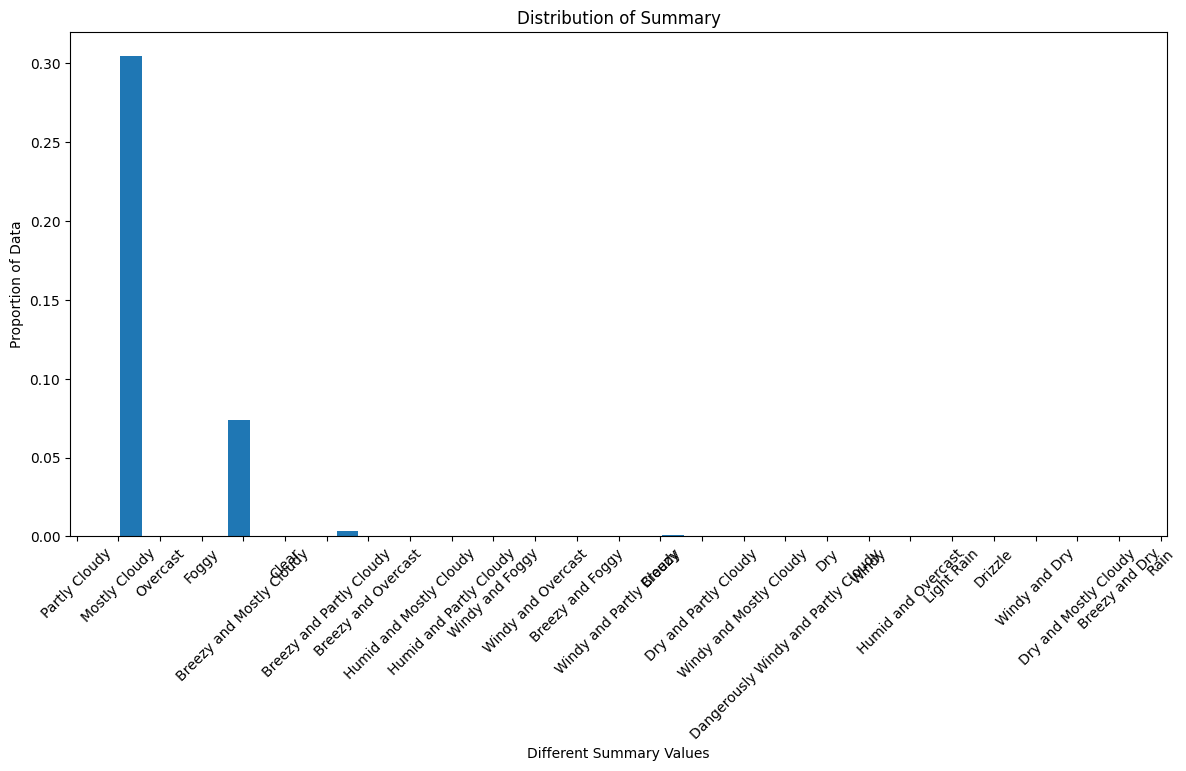

In [7]:

summary_col = weather_data.get_column('Summary')
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(x = summary_col, density=True, rwidth = .2, histtype = 'barstacked')
plt.title('Distribution of Summary')
plt.xlabel('Different Summary Values')
plt.ylabel('Proportion of Data')
plt.tight_layout()
plt.xticks(rotation = 45, fontsize = 10)
plt.show()


#### Random Forest

Probably want stratified k fold cross validation, although some summaries happen so rarely that it might not be useful.

In [9]:
# hyperparameters N, M, F dont forget to tune
forest_classifier = MyRandomForestClassifier(20, 5, 4)


k = 10 # number of splits




y_possibilities = list(set(all_ys))

forest_classifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(forest_classifier, discretized_xs, all_ys, num_splits=k, random_state=seed)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"{k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Random Forest Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Random Forest Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Random Forest Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))




Weather Classification Results
10-Fold Cross Validation
-------------------------------------------
Random Forest Classifier: accuracy = 0.38, error rate = 0.62
Random Forest Classifier: Precision = 0.29, Recall = 0.33, F1 Score = 0.31
-------------------------------------------
Random Forest Classifier Confusion Matrix
| Summary                             |   Humid and Overcast |   Foggy |   Windy and Mostly Cloudy |   Windy and Foggy |   Light Rain |   Dry and Mostly Cloudy |   Drizzle |   Partly Cloudy |   Windy and Overcast |   Breezy |   Breezy and Dry |   Breezy and Mostly Cloudy |   Dry |   Rain |   Breezy and Foggy |   Breezy and Partly Cloudy |   Dangerously Windy and Partly Cloudy |   Humid and Mostly Cloudy |   Dry and Partly Cloudy |   Clear |   Windy and Partly Cloudy |   Windy |   Breezy and Overcast |   Overcast |   Windy and Dry |   Humid and Partly Cloudy |   Mostly Cloudy |   Total |   Recognition (%) |
|-------------------------------------|----------------------|--

#### Decision Tree

In [9]:
tree_classifier = MyDecisionTreeClassifier()

y_possibilities = list(set(all_ys))

tree_classifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(tree_classifier, discretized_xs, all_ys, num_splits=k, random_state=seed)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"{k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Decision Tree Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Decision Tree Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Decision Tree Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))

Weather Classification Results
10-Fold Cross Validation
-------------------------------------------
Decision Tree Classifier: accuracy = 0.40, error rate = 0.60
Decision Tree Classifier: Precision = 0.24, Recall = 0.33, F1 Score = 0.28
-------------------------------------------
Decision Tree Classifier Confusion Matrix
| Summary                             |   Dangerously Windy and Partly Cloudy |   Dry and Mostly Cloudy |   Breezy and Dry |   Windy and Partly Cloudy |   Breezy and Foggy |   Foggy |   Dry and Partly Cloudy |   Dry |   Windy and Overcast |   Breezy |   Mostly Cloudy |   Breezy and Mostly Cloudy |   Rain |   Humid and Overcast |   Windy |   Windy and Foggy |   Light Rain |   Windy and Dry |   Windy and Mostly Cloudy |   Drizzle |   Clear |   Breezy and Overcast |   Breezy and Partly Cloudy |   Partly Cloudy |   Humid and Mostly Cloudy |   Humid and Partly Cloudy |   Overcast |   Total |   Recognition (%) |
|-------------------------------------|-------------------------

#### Naive Bayes

In [10]:
naiveClassifier = MyNaiveBayesClassifier()

naiveClassifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(
  naiveClassifier, discretized_xs, all_ys, num_splits=k, random_state=seed)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myutils.myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"{k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Naive Bayes Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Naive Bayes Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Naive Bayes Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))

Weather Classification Results
10-Fold Cross Validation
-------------------------------------------
Naive Bayes Classifier: accuracy = 0.39, error rate = 0.61
Naive Bayes Classifier: Precision = 0.30, Recall = 0.34, F1 Score = 0.32
-------------------------------------------
Naive Bayes Classifier Confusion Matrix
| Summary                             |   Dangerously Windy and Partly Cloudy |   Dry and Mostly Cloudy |   Breezy and Dry |   Windy and Partly Cloudy |   Breezy and Foggy |   Foggy |   Dry and Partly Cloudy |   Dry |   Windy and Overcast |   Breezy |   Mostly Cloudy |   Breezy and Mostly Cloudy |   Rain |   Humid and Overcast |   Windy |   Windy and Foggy |   Light Rain |   Windy and Dry |   Windy and Mostly Cloudy |   Drizzle |   Clear |   Breezy and Overcast |   Breezy and Partly Cloudy |   Partly Cloudy |   Humid and Mostly Cloudy |   Humid and Partly Cloudy |   Overcast |   Total |   Recognition (%) |
|-------------------------------------|-------------------------------